In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### ECG Data Preprocessing 

Preprocessing with Pandas 

In [ ]:
# import data and perform data slicing
df= pd.read_csv("./ecgmotion_combined.csv")
df = df.iloc[0:201,1:]
#df.to_csv('./processed_ecgmotion.csv')
df

,Jump,Jump.1,Jump.2,Jump.3,Jump.4,Jump.5,Jump.6,Jump.7,Jump.8,Jump.9,...,Walk.43,Walk.44,Walk.45,Walk.46,Walk.47,Walk.48,Walk.49,Walk.50,Walk.51,Walk.52
0,3051.0,3362.0,892.0,3724.0,2682.0,2721.0,2168.0,2998.0,2090.0,1222.0,...,1662.0,1648.0,1780.0,1762.0,1560.0,1496,1516.0,2016.0,2126.0,1851.0
1,3109.0,3586.0,799.0,4050.0,2683.0,2357.0,2576.0,3049.0,2083.0,772.0,...,1843.0,1716.0,1800.0,1797.0,1451.0,1501,1733.0,2048.0,2319.0,1938.0
2,2245.0,3714.0,800.0,2568.0,2588.0,2453.0,2116.0,3130.0,2070.0,859.0,...,1846.0,1845.0,1806.0,1797.0,1279.0,1645,1824.0,2148.0,2375.0,1865.0
3,1755.0,3459.0,826.0,1423.0,2483.0,2100.0,2102.0,2768.0,2006.0,1646.0,...,1850.0,1990.0,1847.0,3108.0,1245.0,1757,1959.0,2288.0,2428.0,1855.0
4,1319.0,3404.0,952.0,576.0,2095.0,1714.0,1917.0,2969.0,2318.0,1641.0,...,1816.0,2080.0,1861.0,2767.0,1401.0,1816,1952.0,2248.0,2393.0,1899.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,2648.0,892.0,3336.0,171.0,17.0,2514.0,2298.0,2050.0,2567.0,4044.0,...,1516.0,1655.0,1960.0,2191.0,2662.0,3019,1624.0,1715.0,1385.0,3012.0
197,2571.0,1379.0,3170.0,397.0,0.0,2353.0,3111.0,1937.0,2859.0,-8.0,...,1509.0,1789.0,2049.0,2338.0,2888.0,3091,3443.0,1653.0,1456.0,3730.0
198,2519.0,1282.0,2864.0,708.0,512.0,2439.0,3059.0,1978.0,2938.0,1136.0,...,1466.0,1792.0,2127.0,2323.0,3106.0,3055,207.0,1438.0,1475.0,1401.0
199,2541.0,1546.0,2523.0,1409.0,527.0,2139.0,3220.0,1961.0,2734.0,1091.0,...,1640.0,1860.0,2312.0,2012.0,3097.0,2784,1812.0,1395.0,1543.0,1824.0


In [9]:
class_labels = df.columns[1:]
unified_labels = class_labels.str.extract(r'([a-zA-Z]+)')[0]
print(unified_labels)

0      Jump
1      Jump
2      Jump
3      Jump
4      Jump
       ... 
217    Walk
218    Walk
219    Walk
220    Walk
221    Walk
Name: 0, Length: 222, dtype: object


In [10]:
scaler = StandardScaler()
y = unified_labels.values
X = df.iloc[1:, 1:].T.values
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

print(X.shape)
print(X)
print(y.shape)
print(y)

(222, 200)
[[ 2.07950667  2.47154421  2.11223795 ... -1.13043018 -0.72425435
  -1.40589123]
 [-1.65165407 -1.78770287 -1.68872133 ...  0.95163106  0.62754998
  -0.02725009]
 [ 2.70069741  0.79649371 -0.82690109 ... -1.88586833 -0.91381135
  -0.33731127]
 ...
 [ 0.02047358  0.18260086  0.42179993 ... -0.92511947 -0.93318214
  -0.92948821]
 [ 0.3832811   0.51439533  0.62390183 ... -0.87642398 -0.72840523
  -0.53426001]
 [-0.12679147 -0.23104599 -0.20327237 ... -0.97381496 -0.33960583
  -0.23750617]]
(222,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
svc = SVC(kernel='rbf', C=5)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
plain_svm_accruacy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(X_train.shape)

plain_svm_accruacy

(155, 200)


0.6567164179104478

In [12]:
def extract_statistical_features(X):
    features = []
    for x in X:
        feature_vector = [
            np.mean(x),         # Mean
            np.std(x),          # Standard Deviation
            np.var(x),          # Variance
            np.min(x),          # Minimum value
            np.max(x),          # Maximum value
            np.median(x),       # Median
            np.percentile(x, 25), # 25th percentile
            np.percentile(x, 75), # 75th percentile
        ]
        features.append(feature_vector)
    return np.array(features)

# Extract features
X_features = extract_statistical_features(X)

In [13]:
from scipy.fft import fft

def extract_frequency_features(X):
    features = []
    for x in X:
        # Apply FFT
        fft_values = fft(x)
        fft_magnitudes = np.abs(fft_values)
        # Select key frequency features
        feature_vector = [
            np.mean(fft_magnitudes),  # Mean of FFT magnitudes
            np.max(fft_magnitudes),   # Max of FFT magnitudes
            np.var(fft_magnitudes),   # Variance of FFT magnitudes
        ]
        features.append(feature_vector)
    return np.array(features)

# Extract frequency features
X_freq_features = extract_frequency_features(X)

In [14]:
# Concatenate statistical and frequency features
X_combined_features = np.hstack((X_features, X_freq_features))
X_train, X_test, y_train, y_test = train_test_split(X_combined_features, y, test_size=0.3, random_state=42)
svc = SVC(kernel='rbf', C=0.1)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
feature_engineered_svm_accruacy = accuracy_score(y_test, y_pred)
#report = classification_report(y_test, y_pred)

feature_engineered_svm_accruacy

0.23880597014925373

# Unsupervised Learning

c:\Users\WonResearchGroup\.conda\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\WonResearchGroup\.conda\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


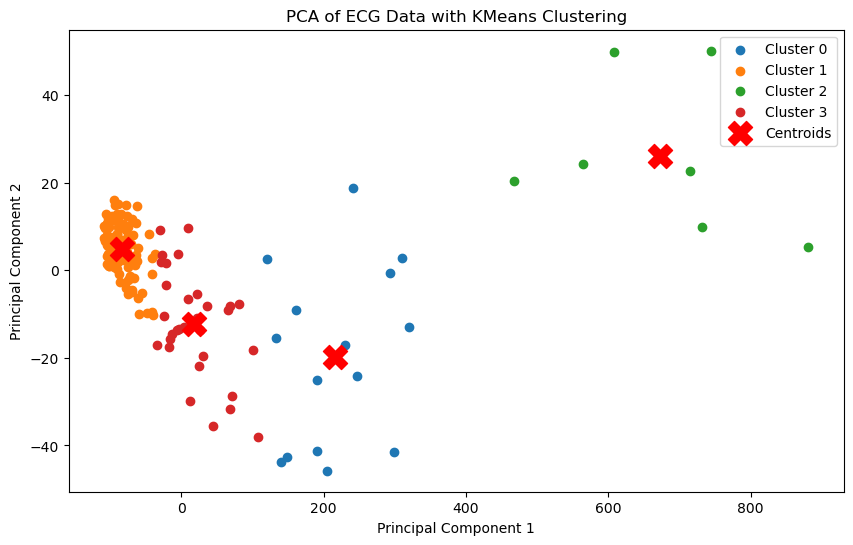

In [15]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import mode

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
kmeans = KMeans(n_clusters=len(set(y_train)), random_state=42)  # n_clusters can be set to the number of classes
X_train_clusters = kmeans.fit_predict(X_train_pca)

# Plotting the Clusters
plt.figure(figsize=(10, 6))

# Scatter plot, colored by cluster assignment
for cluster in range(len(set(X_train_clusters))):
    mask = (X_train_clusters == cluster)
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=f'Cluster {cluster}')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')

plt.title('PCA of ECG Data with KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Deep Learning
### RNN

In [16]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM, Conv1D, MaxPooling1D, GRU, Embedding, Flatten, Dropout, TimeDistributed, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
tf.random.set_seed(42)

# X and y are scaled already
n_samples, n_features = X_train.shape
time_steps = 1

X_train_rnn = X_train.reshape((n_samples, time_steps, n_features))
X_test_rnn = X_test.reshape((X_test.shape[0], time_steps, X_test.shape[1]))

n_classes = len(np.unique(y_train))
y_train_one_hot = to_categorical(y_train, num_classes=n_classes)
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)
n_units = 300


rnn_model = Sequential([
    SimpleRNN(n_units, input_shape=(time_steps, n_features), activation='relu'),
    Dense(n_units, activation='relu'),
    Dense(n_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()
# input_array_shape = total_samples * time_steps * features

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn (SimpleRNN)       (None, 300)               93600     
_________________________________________________________________
dense (Dense)                (None, 300)               90300     
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 1204      
Total params: 185,104
Trainable params: 185,104
Non-trainable params: 0
_________________________________________________________________


In [17]:
history = rnn_model.fit(X_train_rnn, y_train_one_hot, epochs=150, batch_size=32,
                    validation_data=(X_test_rnn, y_test_one_hot))

rnn_y_pred_prob = rnn_model.predict(X_test_rnn)
rnn_y_pred = np.argmax(rnn_y_pred_prob, axis=1)

rnn_accuracy = accuracy_score(y_test, rnn_y_pred)

Epoch 1/150
5/5 [==============================] - 2s 53ms/step - loss: 5.0026 - accuracy: 0.3484 - val_loss: 3.7924 - val_accuracy: 0.4776
Epoch 2/150
5/5 [==============================] - 0s 8ms/step - loss: 3.7475 - accuracy: 0.4452 - val_loss: 2.1172 - val_accuracy: 0.5821
Epoch 3/150
5/5 [==============================] - 0s 8ms/step - loss: 2.0219 - accuracy: 0.4839 - val_loss: 1.5928 - val_accuracy: 0.3582
Epoch 4/150
5/5 [==============================] - 0s 8ms/step - loss: 2.0643 - accuracy: 0.4387 - val_loss: 1.3373 - val_accuracy: 0.5821
Epoch 5/150
5/5 [==============================] - 0s 8ms/step - loss: 1.7206 - accuracy: 0.4645 - val_loss: 1.5626 - val_accuracy: 0.5373
Epoch 6/150
5/5 [==============================] - 0s 8ms/step - loss: 1.5425 - accuracy: 0.4968 - val_loss: 1.5108 - val_accuracy: 0.5075
Epoch 7/150
5/5 [==============================] - 0s 8ms/step - loss: 1.2461 - accuracy: 0.5742 - val_loss: 1.1195 - val_accuracy: 0.5075
Epoch 8/150
5/5 [=========

In [18]:
lstm_model = Sequential([
    LSTM(n_units, input_shape=(time_steps, n_features), activation='relu'),
    Dense(n_units, activation='relu'),
    Dense(n_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 300)               374400    
_________________________________________________________________
dense_2 (Dense)              (None, 300)               90300     
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 1204      
Total params: 465,904
Trainable params: 465,904
Non-trainable params: 0
_________________________________________________________________


In [19]:
history = lstm_model.fit(X_train_rnn, y_train_one_hot, epochs=150, batch_size=32,
                    validation_data=(X_test_rnn, y_test_one_hot))

lstm_y_pred_prob = lstm_model.predict(X_test_rnn)
lstm_y_pred = np.argmax(lstm_y_pred_prob, axis=1)

lstm_accuracy = accuracy_score(y_test, lstm_y_pred)

Epoch 1/150
5/5 [==============================] - 1s 55ms/step - loss: 2.0621 - accuracy: 0.3097 - val_loss: 1.3360 - val_accuracy: 0.4925
Epoch 2/150
5/5 [==============================] - 0s 15ms/step - loss: 1.3004 - accuracy: 0.4839 - val_loss: 0.9990 - val_accuracy: 0.6269
Epoch 3/150
5/5 [==============================] - 0s 14ms/step - loss: 1.0796 - accuracy: 0.5613 - val_loss: 0.9358 - val_accuracy: 0.4776
Epoch 4/150
5/5 [==============================] - 0s 15ms/step - loss: 0.9669 - accuracy: 0.5419 - val_loss: 0.9860 - val_accuracy: 0.5970
Epoch 5/150
5/5 [==============================] - 0s 14ms/step - loss: 0.9213 - accuracy: 0.5677 - val_loss: 0.9529 - val_accuracy: 0.6119
Epoch 6/150
5/5 [==============================] - 0s 14ms/step - loss: 0.8646 - accuracy: 0.5871 - val_loss: 0.8940 - val_accuracy: 0.5821
Epoch 7/150
5/5 [==============================] - 0s 15ms/step - loss: 0.8400 - accuracy: 0.6065 - val_loss: 0.8750 - val_accuracy: 0.6119
Epoch 8/150
5/5 [===

In [70]:
gru_model = Sequential([
    GRU(n_units, input_shape=(time_steps, n_features), activation='relu'),
    Dense(n_units, activation='relu'),
    Dense(n_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
gru_model.summary()

Model: "sequential_25"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
gru_1 (GRU)                  (None, 300)               281700    
_________________________________________________________________
dense_58 (Dense)             (None, 300)               90300     
_________________________________________________________________
dense_59 (Dense)             (None, 4)                 1204      
Total params: 373,204
Trainable params: 373,204
Non-trainable params: 0
_________________________________________________________________


In [71]:
history = gru_model.fit(X_train_rnn, y_train_one_hot, epochs=150, batch_size=32,
                    validation_data=(X_test_rnn, y_test_one_hot))

gru_y_pred_prob = gru_model.predict(X_test_rnn)
gru_y_pred = np.argmax(gru_y_pred_prob, axis=1)

gru_accuracy = accuracy_score(y_test, gru_y_pred)
print(gru_accuracy)

Epoch 1/150
5/5 [==============================] - 1s 64ms/step - loss: 1.7626 - accuracy: 0.3935 - val_loss: 1.5114 - val_accuracy: 0.3731
Epoch 2/150
5/5 [==============================] - 0s 25ms/step - loss: 1.3159 - accuracy: 0.4903 - val_loss: 0.9303 - val_accuracy: 0.5970
Epoch 3/150
5/5 [==============================] - 0s 21ms/step - loss: 1.1766 - accuracy: 0.4774 - val_loss: 0.9225 - val_accuracy: 0.5821
Epoch 4/150
5/5 [==============================] - 0s 23ms/step - loss: 1.0730 - accuracy: 0.5871 - val_loss: 0.9520 - val_accuracy: 0.5522
Epoch 5/150
5/5 [==============================] - 0s 21ms/step - loss: 1.0720 - accuracy: 0.5677 - val_loss: 0.9241 - val_accuracy: 0.5672
Epoch 6/150
5/5 [==============================] - 0s 16ms/step - loss: 0.9584 - accuracy: 0.6000 - val_loss: 0.8761 - val_accuracy: 0.5970
Epoch 7/150
5/5 [==============================] - 0s 15ms/step - loss: 1.0882 - accuracy: 0.5419 - val_loss: 0.8732 - val_accuracy: 0.5970
Epoch 8/150
5/5 [===

In [74]:
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', padding="same", input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding="same"),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding="same"),
    Flatten(), 
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dense(y_train_one_hot.shape[1], activation='softmax')  # Output layer with softmax for classification
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_26"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_62 (Conv1D)           (None, 11, 32)            128       
_________________________________________________________________
max_pooling1d_48 (MaxPooling (None, 5, 32)             0         
_________________________________________________________________
conv1d_63 (Conv1D)           (None, 5, 64)             6208      
_________________________________________________________________
max_pooling1d_49 (MaxPooling (None, 2, 64)             0         
_________________________________________________________________
conv1d_64 (Conv1D)           (None, 2, 128)            24704     
_________________________________________________________________
flatten_13 (Flatten)         (None, 256)               0         
_________________________________________________________________
dense_60 (Dense)             (None, 128)             

In [75]:
history = cnn_model.fit(
    X_train_cnn, 
    y_train_one_hot, 
    epochs=150,           # You can adjust the number of epochs based on performance
    batch_size=32,       # Smaller batch size may help if memory is limited
    validation_data=(X_test_cnn, y_test_one_hot),  # Include validation data to track testing accuracy
    verbose=1
)

cnn_y_pred_prob = cnn_model.predict(X_test_cnn)
cnn_y_pred = np.argmax(cnn_y_pred_prob, axis=1)

cnn_y_test_classes = np.argmax(y_test_one_hot, axis=1)

cnn_accuracy = accuracy_score(cnn_y_test_classes, cnn_y_pred)
print(cnn_accuracy)

Epoch 1/150
5/5 [==============================] - 1s 51ms/step - loss: 2.3725 - accuracy: 0.2516 - val_loss: 1.4889 - val_accuracy: 0.2388
Epoch 2/150
5/5 [==============================] - 0s 18ms/step - loss: 1.5902 - accuracy: 0.2968 - val_loss: 1.2856 - val_accuracy: 0.2388
Epoch 3/150
5/5 [==============================] - 0s 18ms/step - loss: 1.4471 - accuracy: 0.3742 - val_loss: 1.2777 - val_accuracy: 0.2388
Epoch 4/150
5/5 [==============================] - 0s 18ms/step - loss: 1.4644 - accuracy: 0.2839 - val_loss: 1.2520 - val_accuracy: 0.2388
Epoch 5/150
5/5 [==============================] - 0s 17ms/step - loss: 1.4477 - accuracy: 0.2968 - val_loss: 1.2325 - val_accuracy: 0.5522
Epoch 6/150
5/5 [==============================] - 0s 14ms/step - loss: 1.2949 - accuracy: 0.4129 - val_loss: 1.2239 - val_accuracy: 0.5672
Epoch 7/150
5/5 [==============================] - 0s 16ms/step - loss: 1.2816 - accuracy: 0.4000 - val_loss: 1.2266 - val_accuracy: 0.5075
Epoch 8/150
5/5 [===

Plain SVM: 0.6567164179104478
CNN: 0.7014925373134329
RNN: 0.6716417910447762
LSTM: 0.7611940298507462
GRU: 0.6417910447761194


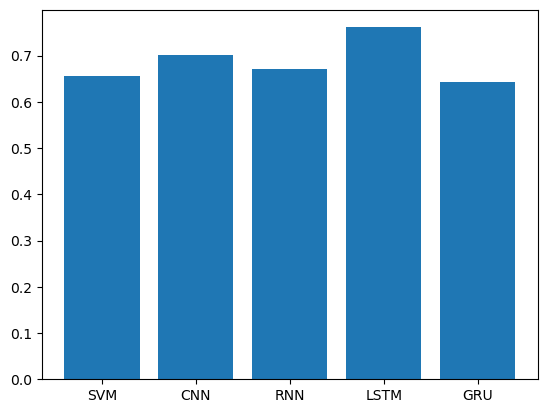

In [77]:
print("Plain SVM:", plain_svm_accruacy)
print("CNN:", cnn_accuracy)
print("RNN:", rnn_accuracy)
print("LSTM:", lstm_accuracy)
print("GRU:", gru_accuracy)


accuracy_dict = {'SVM':plain_svm_accruacy, 'CNN': cnn_accuracy, 'RNN':rnn_accuracy, 'LSTM':lstm_accuracy, 'GRU':gru_accuracy}
names = list(accuracy_dict.keys())
values = list(accuracy_dict.values())
plt.bar(range(len(accuracy_dict)), values, tick_label=names)
plt.show()